# 03 — Evaluation

Loads an attribution CSV from `results/` and produces two figures:
- **QQ analysis** — log-log Type I error control and power curves
- **Time evolution** — rolling yearly Type I error rate and statistical power

Figures are saved in `figures/` with a timestamp.

**Set `RESULTS_PATH` below** (or leave it as `None` to auto-select the latest file).

In [8]:
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

In [9]:
import sys, os, glob
import numpy as np
import pandas as pd

SRC_PATH = 'src'
sys.path.insert(0, SRC_PATH)

from visualization import plot_time_evolution, plot_qq_analysis
from config import STYLE_CONFIG

In [10]:
# ================================================================
#  CONFIG  —  edit here
# ================================================================
RESULTS_DIR = 'results'
FIGURES_DIR = 'figures'

# Path to the CSV to evaluate.
# Set to None to automatically pick the most recently created file.
RESULTS_PATH = None

# Rolling window for time-evolution plot (years; 1 = no smoothing)
SMOOTHING_WINDOW = 3
# ================================================================

In [11]:
# Auto-select the latest results file if RESULTS_PATH is not set
if RESULTS_PATH is None:
    csv_files = sorted(
        glob.glob(os.path.join(RESULTS_DIR, 'attribution_*.csv')),
        key=os.path.getmtime
    )
    if not csv_files:
        raise FileNotFoundError(
            f'No attribution_*.csv found in {RESULTS_DIR}.\n'
            'Run 02_attribution.ipynb first, or set RESULTS_PATH manually.')
    RESULTS_PATH = csv_files[-1]

print(f'Loading: {RESULTS_PATH}')
df = pd.read_csv(RESULTS_PATH, parse_dates=['time'])
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Loading: results/attribution_20260324_2221.csv
Shape: (426, 13)
Columns: ['member', 'event_id', 'scenario', 'time', 'lat', 'lon', 'pn_ensemble_gaussian', 'pn_thermo_ML_gaussian', 'pn_analogues_local_gaussian', 'pn_dynamical_adjustment_local_gaussian', 'pn_analogue_sparse_sir_2_gaussian', 'pn_analogue_sparse_sir_3_gaussian', 'pn_analogue_sparse_sir_10_gaussian']


,member,event_id,scenario,time,lat,lon,pn_ensemble_gaussian,pn_thermo_ML_gaussian,pn_analogues_local_gaussian,pn_dynamical_adjustment_local_gaussian,pn_analogue_sparse_sir_2_gaussian,pn_analogue_sparse_sir_3_gaussian,pn_analogue_sparse_sir_10_gaussian
0,r1i1p1f1,0,factual,2004-02-15 12:00:00,43.774647,50.750000,0.868749,0.928612,0.299978,0.785486,0.996267,0.858448,0.922376
1,r1i1p1f1,1,factual,2004-06-16 00:00:00,-72.351030,43.230770,0.720876,0.761629,0.511571,0.876626,0.999747,0.996141,0.999682
2,r1i1p1f1,2,factual,2004-12-16 12:00:00,63.058010,151.652540,0.888448,0.995977,0.999999,0.969202,0.964630,0.997530,0.999581
3,r1i1p1f1,3,factual,2005-05-16 12:00:00,-19.544710,21.744186,0.642460,0.995962,1.000000,0.987145,0.999999,1.000000,1.000000
4,r1i1p1f1,4,factual,2006-04-16 00:00:00,51.557922,75.000000,0.977754,0.872158,0.000000,0.395108,0.999999,0.999967,0.999547


## Define algo_groups

Each entry maps a **group name** to a list of `(display_label, csv_column, color)` tuples.
- `display_label` appears in the legend; suffix `(Emp)`, `(GEV)`, or `(Norm)` controls line style.
- `csv_column` must match a column name in the results CSV (e.g. `pn_thermo_ML_gaussian`).
- Groups are plotted as separate row-panels in the time-evolution figure.

Edit this cell to reflect the methods present in your results file.

In [12]:
# Discover available PN columns automatically
pn_cols = [c for c in df.columns if c.startswith('pn_')]
print('Available PN columns:')
for c in pn_cols:
    print(' ', c)

Available PN columns:
  pn_ensemble_gaussian
  pn_thermo_ML_gaussian
  pn_analogues_local_gaussian
  pn_dynamical_adjustment_local_gaussian
  pn_analogue_sparse_sir_2_gaussian
  pn_analogue_sparse_sir_3_gaussian
  pn_analogue_sparse_sir_10_gaussian


In [13]:
C = STYLE_CONFIG  # shorthand

algo_groups = {
    'Ensemble (reference)': [
        ('Ensemble (Norm)', 'pn_ensemble_gaussian',       C['Simulation']['color']),
    ],
    'Thermodynamic': [
        ('Thermo ML (Norm)', 'pn_thermo_ML_gaussian',     C['Thermo ML']['color']),
    ],
    'Dynamical Adjustment': [
        ('DA Global PCA (Norm)', 'pn_dyn_adj_global_pca_gaussian',  C['DynAdj Global PCA']['color']),
        ('DA Local 50 (Norm)',   'pn_dynamical_adjustment_local_gaussian',    C['DynAdj Local 50']['color']),
        ('DA Local 25 (Norm)', 'pn_dyn_adj_local_25_gaussian', C['DynAdj Local 25']['color']),
    ],
    'Analogues': [
        ('Analogues Local (Norm)', 'pn_analogues_local_gaussian',   C['Analogues']['color']),
        ('Analogues Unconditional - 10 (Norm)', 'pn_analogue_sparse_sir_10_gaussian',   C['DynAdj Global PCA']['color']),
        ('Analogues Unconditional - 3 (Norm)', 'pn_analogue_sparse_sir_3_gaussian',   C['DynAdj Local 25']['color']),
        ('Analogues Unconditional - 2 (Norm)', 'pn_analogue_sparse_sir_2_gaussian',   C['Analogues Lasso']['color']),
    ],
    # Uncomment and adjust for custom methods:
    # 'My Method': [
    #     ('My Method (Norm)', 'pn_my_method_gaussian', '#e74c3c'),
    # ],
}

# Filter out groups whose columns are missing in this results file
algo_groups = {
    g: [(lbl, col, clr) for lbl, col, clr in entries if col in df.columns]
    for g, entries in algo_groups.items()
}
algo_groups = {g: e for g, e in algo_groups.items() if e}
print('Groups to plot:', list(algo_groups.keys()))

Groups to plot: ['Ensemble (reference)', 'Thermodynamic', 'Dynamical Adjustment', 'Analogues']


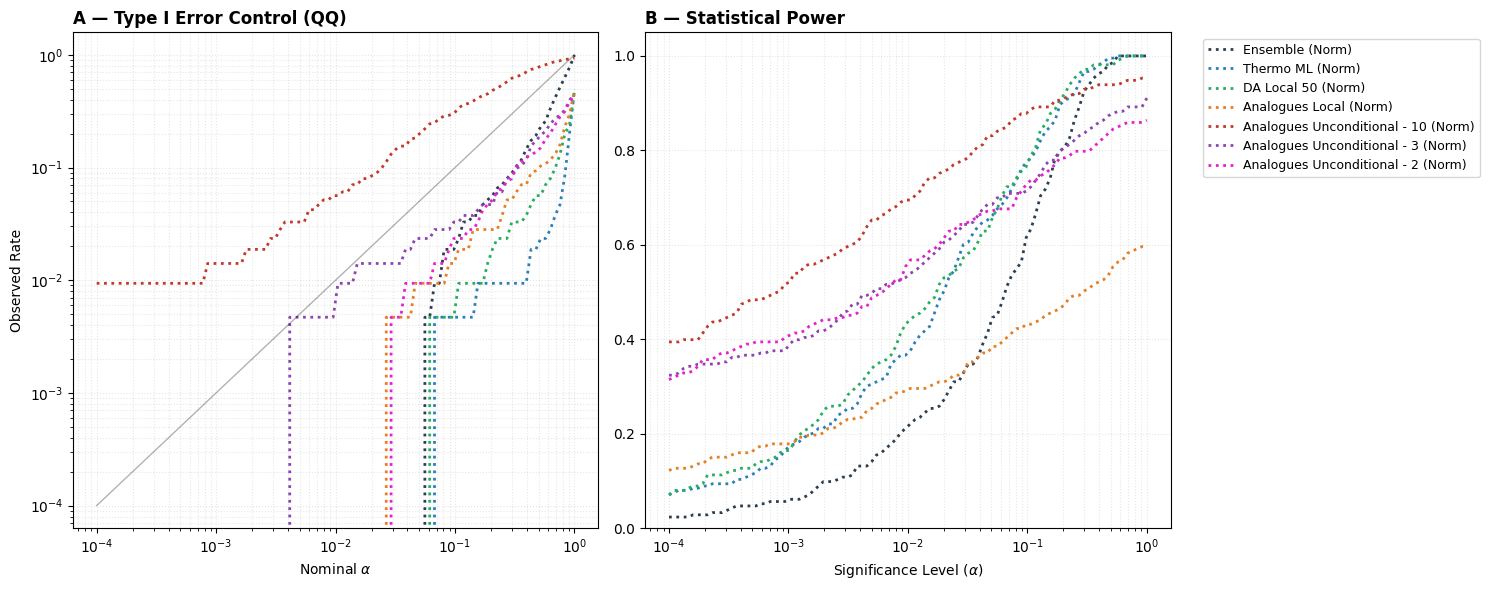

Saved -> figures/qq_analysis_20260324_2222.png


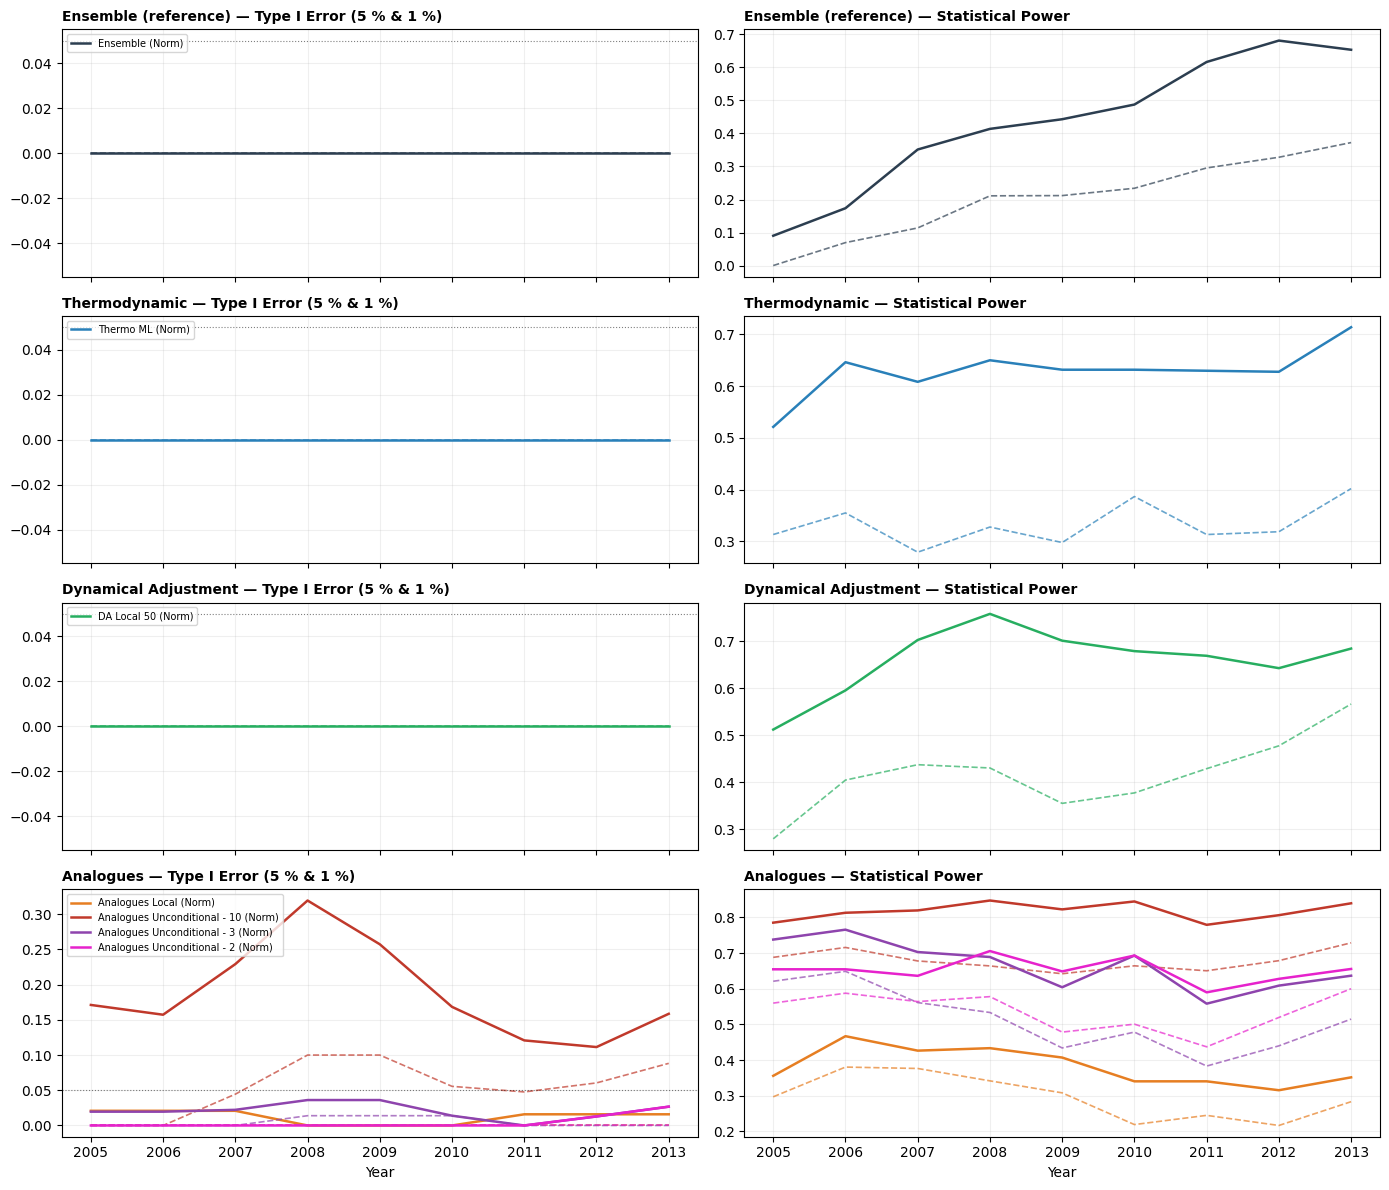

Saved -> figures/time_evolution_20260324_2222.png


In [14]:
os.makedirs(FIGURES_DIR, exist_ok=True)
from datetime import datetime
ts = datetime.now().strftime('%Y%m%d_%H%M')

qq_path  = os.path.join(FIGURES_DIR, f'qq_analysis_{ts}.png')
evo_path = os.path.join(FIGURES_DIR, f'time_evolution_{ts}.png')

plot_qq_analysis(
    df, algo_groups,
    save_path=qq_path)

plot_time_evolution(
    df, algo_groups,
    window=SMOOTHING_WINDOW,
    save_path=evo_path)